In [ ]:
# Travel & Hospitality Data Analysis - EDA
## Customer Retention & Dynamic Pricing Analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

file_path = r"C:\Users\AMRIT\OneDrive\Desktop\travel_hospitality_large_dataset.xlsx"

In [2]:
excel = pd.ExcelFile(file_path)
excel.sheet_names

['customers',
 'hotels',
 'rooms',
 'bookings',
 'payments',
 'cancellations',
 'reviews',
 'seasonal_pricing',
 'employees',
 'locations']

In [3]:
customers = pd.read_excel(file_path, sheet_name="customers")
hotels = pd.read_excel(file_path, sheet_name="hotels")
rooms = pd.read_excel(file_path, sheet_name="rooms")
bookings = pd.read_excel(file_path, sheet_name="bookings")
payments = pd.read_excel(file_path, sheet_name="payments")
cancellations = pd.read_excel(file_path, sheet_name="cancellations")
reviews = pd.read_excel(file_path, sheet_name="reviews")
seasonal = pd.read_excel(file_path, sheet_name="seasonal_pricing")
employees = pd.read_excel(file_path, sheet_name="employees")
locations = pd.read_excel(file_path, sheet_name="locations")

In [5]:
customers.head()
bookings.head()
hotels.head()

,hotel_id,hotel_name,city,country,hotel_type,star_rating,total_rooms,hotel_revenue,occupancy_rate,customer_rating
0,1,Sky Hotel 1,Ahmedabad,India,City Hotel,3.6,428,21780483,47.45,4.4
1,2,Sky Hotel 2,Ahmedabad,India,City Hotel,3.1,87,45132224,92.49,2.5
2,3,Elite Hotel 3,Hyderabad,India,City Hotel,4.6,169,47794495,63.98,4.5
3,4,Royal Hotel 4,Bangalore,India,Business Hotel,3.7,291,34004340,57.65,3.0
4,5,Grand Hotel 5,Goa,India,Business Hotel,4.9,126,17463444,87.73,4.9


In [6]:
# EDA 
#MAIN TABLE IS BOOKING 
bookings.info()
bookings.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   booking_id           12000 non-null  int64         
 1   customer_id          12000 non-null  int64         
 2   hotel_id             12000 non-null  int64         
 3   room_id              12000 non-null  int64         
 4   booking_date         12000 non-null  datetime64[ns]
 5   check_in_date        12000 non-null  datetime64[ns]
 6   check_out_date       12000 non-null  datetime64[ns]
 7   lead_time            12000 non-null  int64         
 8   adults               12000 non-null  int64         
 9   children             12000 non-null  int64         
 10  meal_plan            12000 non-null  object        
 11  market_segment       12000 non-null  object        
 12  booking_status       12000 non-null  object        
 13  adr                  12000 non-

,booking_id,customer_id,hotel_id,room_id,booking_date,check_in_date,check_out_date,lead_time,adults,children,adr,total_nights,special_requests,discount_percentage,booking_revenue
count,12000.00000,12000.000000,12000.000000,12000.000000,12000,12000,12000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,2511.271333,50.396833,998.124750,2025-05-10 10:16:04.800000,2025-06-24 18:31:48,2025-07-02 17:50:31.200000256,45.344250,3.00950,2.006583,13932.824917,7.971333,2.497083,19.950000,111091.474250
min,1.00000,1.000000,1.000000,1.000000,2024-05-09 00:00:00,2024-05-11 00:00:00,2024-05-19 00:00:00,1.000000,1.00000,0.000000,3002.000000,1.000000,0.000000,0.000000,3012.000000
25%,3000.75000,1268.750000,26.000000,498.000000,2024-11-07 00:00:00,2024-12-23 00:00:00,2024-12-31 00:00:00,22.000000,2.00000,1.000000,8367.500000,4.000000,1.000000,10.000000,44125.000000
50%,6000.50000,2499.500000,50.000000,998.000000,2025-05-12 00:00:00,2025-06-24 00:00:00,2025-07-01 00:00:00,45.000000,3.00000,2.000000,13954.000000,8.000000,2.000000,20.000000,89512.000000
75%,9000.25000,3757.000000,75.000000,1498.000000,2025-11-10 00:00:00,2025-12-25 00:00:00,2026-01-02 00:00:00,68.000000,4.00000,3.000000,19483.500000,12.000000,4.000000,30.000000,161853.750000
max,12000.00000,5000.000000,100.000000,2000.000000,2026-05-09 00:00:00,2026-08-06 00:00:00,2026-08-21 00:00:00,90.000000,5.00000,4.000000,24997.000000,15.000000,5.000000,40.000000,374925.000000
std,3464.24595,1436.330961,28.794049,578.501437,NaN,NaN,NaN,26.166304,1.40644,1.413343,6391.031834,4.326207,1.709991,11.851197,83689.356303


In [7]:
df = bookings.merge(customers, on="customer_id", how="left")
df = df.merge(hotels, on="hotel_id", how="left")
df = df.merge(rooms, on="room_id", how="left")

In [9]:
df

,booking_id,customer_id,hotel_id_x,room_id,booking_date,check_in_date,check_out_date,lead_time,adults,children,...,customer_rating,hotel_id_y,room_type,room_capacity,base_price,availability_status,floor_number,room_size_sqft,wifi_available,ac_available
0,1,1635,59,1295,2024-07-25,2024-10-09,2024-10-11,76,5,0,...,3.8,14,Suite,3,9782,Booked,15,989,Yes,Yes
1,2,3308,89,483,2025-10-14,2025-11-23,2025-12-05,40,2,0,...,4.0,7,Deluxe,5,3529,Available,6,1064,Yes,No
2,3,4723,24,1572,2026-05-06,2026-05-20,2026-06-04,14,5,2,...,4.4,40,Deluxe,3,17580,Maintenance,7,188,No,No
3,4,1983,100,911,2026-04-02,2026-04-16,2026-04-23,14,3,3,...,4.5,29,Standard,1,2998,Available,4,395,Yes,No
4,5,831,49,608,2026-02-08,2026-03-07,2026-03-18,27,2,3,...,3.7,4,Family Suite,3,13024,Maintenance,16,554,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,11996,2776,64,1056,2025-04-20,2025-07-03,2025-07-06,74,3,4,...,2.9,14,Executive,3,3868,Booked,4,909,Yes,No
11996,11997,4217,94,1981,2024-08-16,2024-08-18,2024-08-20,2,4,2,...,4.4,47,Deluxe,6,13970,Maintenance,1,928,Yes,Yes
11997,11998,1529,70,1284,2025-05-23,2025-06-30,2025-07-01,38,3,2,...,3.6,26,Suite,5,13466,Maintenance,6,1067,No,No
11998,11999,3294,45,1030,2024-07-24,2024-08-26,2024-09-01,33,1,2,...,4.5,99,Family Suite,4,7101,Maintenance,14,637,Yes,Yes


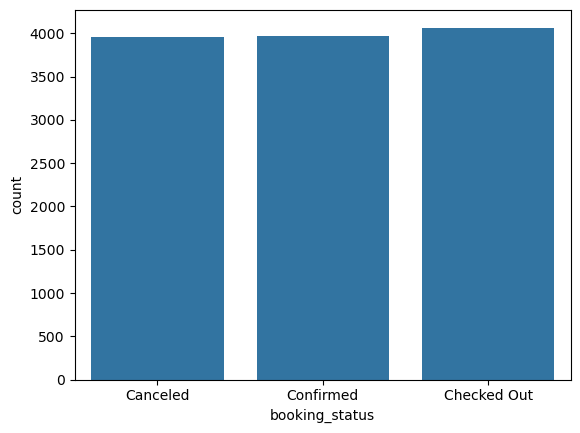

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="booking_status", data=df)
plt.show()

In [11]:
#target analysis  Shows how many bookings are confirmed vs cancelled.
df['booking_status'].value_counts()

booking_status
Checked Out    4067
Confirmed      3971
Canceled       3962
Name: count, dtype: int64

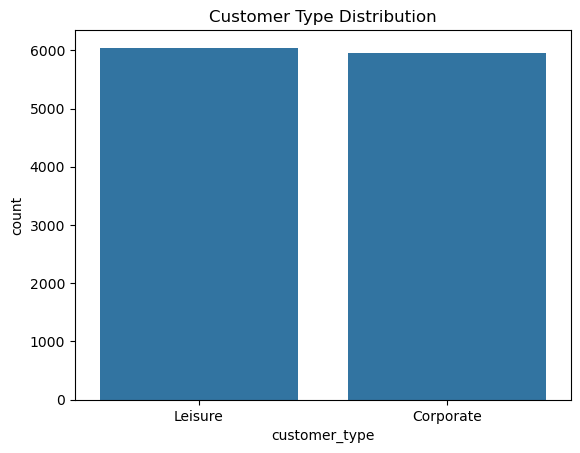

In [13]:
#customer analysis : Shows distribution of different customer categories (Corporate/Leisure).
sns.countplot(x='customer_type', data=df)
plt.title("Customer Type Distribution")
plt.show()

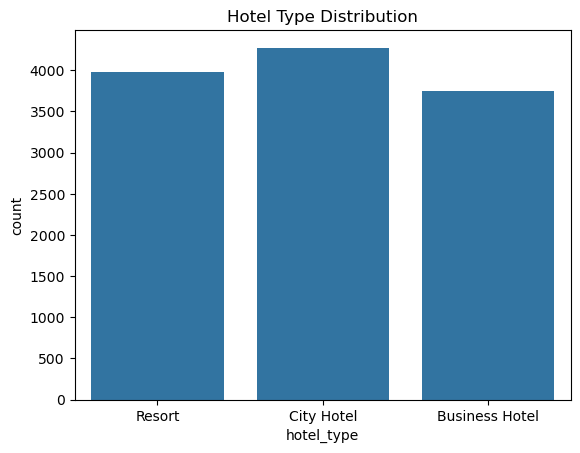

In [14]:
#hotel analysis : Compares booking patterns between hotel types (City vs Resort).
sns.countplot(x='hotel_type', data=df)
plt.title("Hotel Type Distribution")
plt.show()

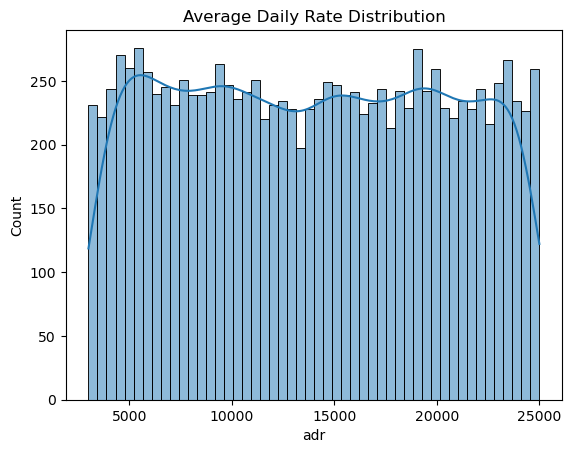

In [15]:
#price analysis : Shows average room price distribution and revenue trends.
sns.histplot(df['adr'], bins=50, kde=True)
plt.title("Average Daily Rate Distribution")
plt.show()

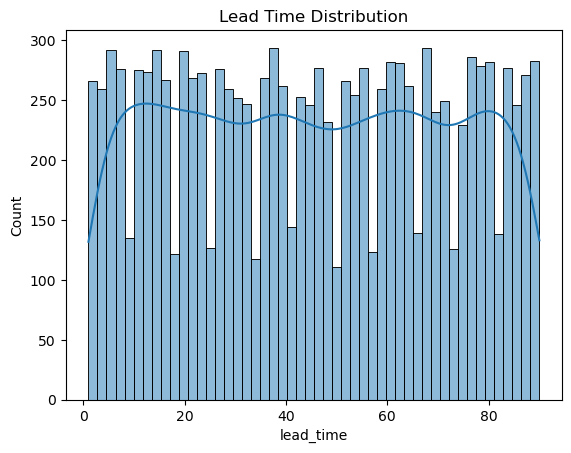

In [16]:
#lead time analysis : Shows how early customers book before arrival.
sns.histplot(df['lead_time'], bins=50, kde=True)
plt.title("Lead Time Distribution")
plt.show()


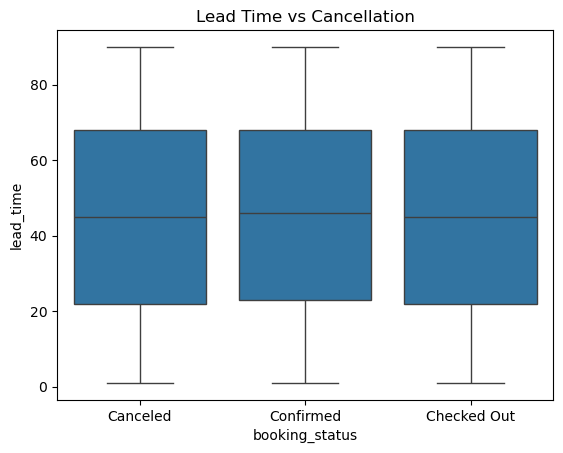

In [17]:
# lead time vs cancellation Shows relationship between booking advance time and cancellation rate.
sns.boxplot(x='booking_status', y='lead_time', data=df)
plt.title("Lead Time vs Cancellation")
plt.show()

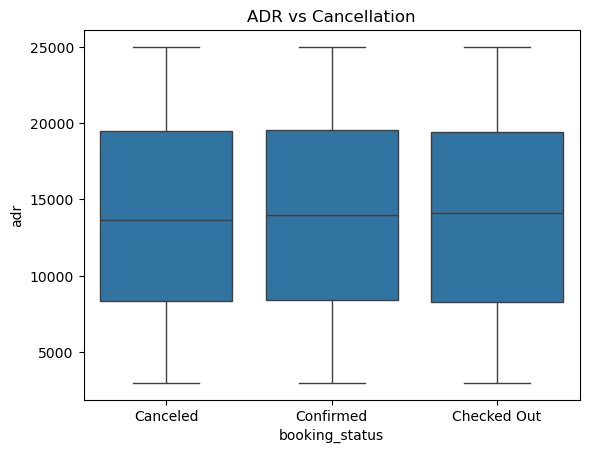

In [18]:
# adr vs cancellation : Shows how room price affects booking cancellations.
sns.boxplot(x='booking_status', y='adr', data=df)
plt.title("ADR vs Cancellation")
plt.show()

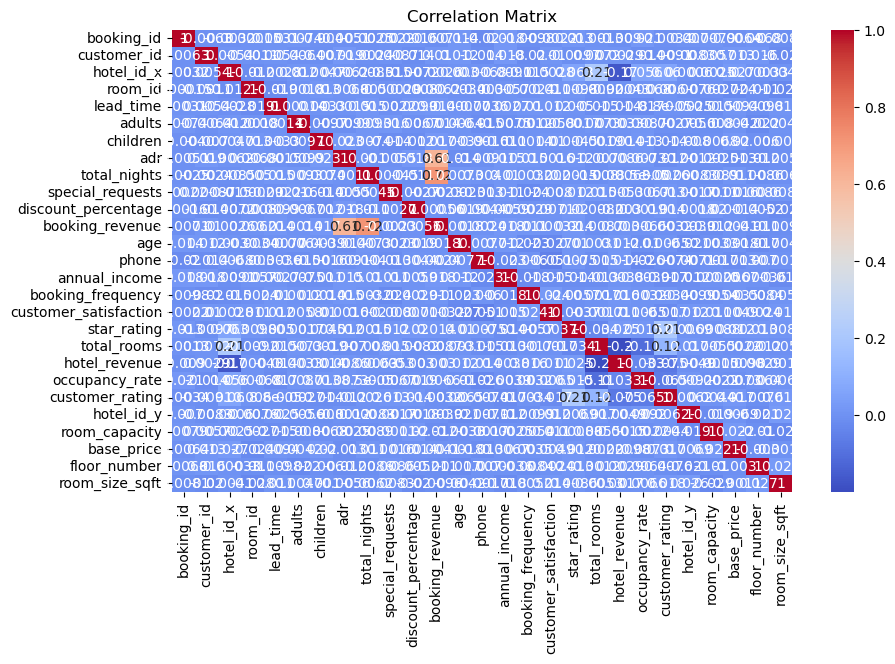

In [23]:
# correlation heatmap : Shows relationships between numerical features affecting bookings.
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [24]:
#Missing Values Analysis: Identifies missing or incomplete data in each column of the dataset.
df.isnull().sum()

booking_id               0
customer_id              0
hotel_id_x               0
room_id                  0
booking_date             0
check_in_date            0
check_out_date           0
lead_time                0
adults                   0
children                 0
meal_plan                0
market_segment           0
booking_status           0
adr                      0
total_nights             0
special_requests         0
booking_channel          0
discount_percentage      0
booking_revenue          0
first_name               0
last_name                0
gender                   0
age                      0
country_x                0
email                    0
phone                    0
customer_type            0
loyalty_status           0
annual_income            0
booking_frequency        0
preferred_channel        0
customer_satisfaction    0
hotel_name               0
city                     0
country_y                0
hotel_type               0
star_rating              0
t

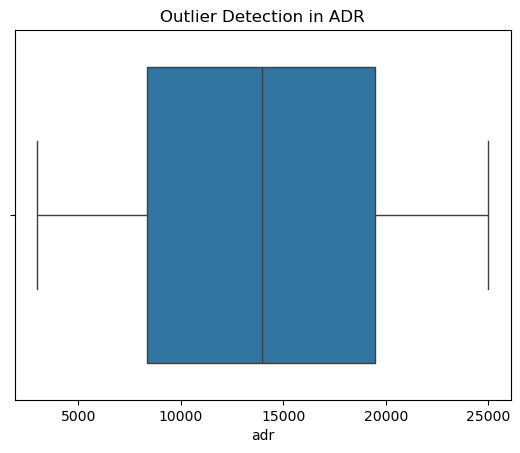

In [25]:
# outlier analysis detects extreme orunsusal values in price 
sns.boxplot(x=df['adr'])
plt.title("Outlier Detection in ADR")
plt.show()

In [ ]:
# key observations from EDA 
# 1. Cancellation Pattern
# A significant portion of bookings are cancelled, showing strong churn behavior in the dataset.
# 2. Lead Time Impact
# Customers who book much earlier (high lead time) tend to cancel more frequently.
# 3. Price (ADR) Effect
# Higher room prices (ADR) are associated with increased cancellation probability in many cases.
# 4. Customer Type Behavior
# Leisure customers show different booking and cancellation patterns compared to corporate customers.
# 5. Hotel Type Insight
# City hotels generally have higher booking volume but also higher cancellation rates compared to resort hotels.
# 6. Seasonal Trend
# Bookings vary across months, showing clear peak and low seasons affecting demand.
# 7. Room & Stay Behavior
# Short stays are more frequent, while longer stays are less common but more stable.
# 8. Revenue Pattern
# Revenue is uneven across hotels, with a few hotels contributing a major share.
# 9. Payment Behavior
# Most customers prefer digital payment methods compared to cash-based transactions.
# 10. Customer Segmentation Insight
# Customers can be broadly grouped into high-value loyal users and price-sensitive users.
# 11. Correlation Insight
# Lead time, ADR, and customer type are among the most influential factors affecting cancellations.
# 12. Outlier Observation
# Some extreme values exist in price and booking duration, indicating special cases or premium bookings.

In [31]:
# Calculating overall cancellation rate
cancel_rate = (df[df['booking_status']=="Canceled"].shape[0] / len(df)) * 100
cancel_rate

33.016666666666666

In [32]:
df.columns

Index(['booking_id', 'customer_id', 'hotel_id_x', 'room_id', 'booking_date',
       'check_in_date', 'check_out_date', 'lead_time', 'adults', 'children',
       'meal_plan', 'market_segment', 'booking_status', 'adr', 'total_nights',
       'special_requests', 'booking_channel', 'discount_percentage',
       'booking_revenue', 'first_name', 'last_name', 'gender', 'age',
       'country_x', 'email', 'phone', 'customer_type', 'loyalty_status',
       'annual_income', 'booking_frequency', 'preferred_channel',
       'customer_satisfaction', 'hotel_name', 'city', 'country_y',
       'hotel_type', 'star_rating', 'total_rooms', 'hotel_revenue',
       'occupancy_rate', 'customer_rating', 'hotel_id_y', 'room_type',
       'room_capacity', 'base_price', 'availability_status', 'floor_number',
       'room_size_sqft', 'wifi_available', 'ac_available'],
      dtype='object')

In [33]:
# Average revenue per booking

df['booking_revenue'].mean()

111091.47425

In [34]:
# Total revenue generated from all bookings

df['booking_revenue'].sum()

1333097691

In [35]:
# Hotel-wise revenue performance

df.groupby('hotel_name')['booking_revenue'].sum().sort_values(ascending=False)

hotel_name
Grand Hotel 93    16546093
Elite Hotel 26    16371898
Grand Hotel 5     16032739
Elite Hotel 34    15634021
Royal Hotel 25    15544041
                    ...   
Elite Hotel 21    10672418
Elite Hotel 98    10614872
Blue Hotel 91     10562011
Grand Hotel 27    10519972
Royal Hotel 73    10385477
Name: booking_revenue, Length: 100, dtype: int64

In [36]:
# City-wise revenue analysis

df.groupby('city')['booking_revenue'].sum().sort_values(ascending=False)

city
Ahmedabad    193042414
Mumbai       174775770
Delhi        163184764
Jaipur       160741570
Chennai      145587298
Goa          130843677
Kolkata      104233964
Hyderabad    102830450
Pune          79821152
Bangalore     78036632
Name: booking_revenue, dtype: int64

In [37]:
# Final Business KPIs

total_bookings = len(df)
total_revenue = df['booking_revenue'].sum()
avg_revenue = df['booking_revenue'].mean()
avg_occupancy = df['occupancy_rate'].mean()

print("Total Bookings:", total_bookings)
print("Total Revenue:", total_revenue)
print("Average Revenue:", avg_revenue)
print("Average Occupancy Rate:", avg_occupancy)


Total Bookings: 12000
Total Revenue: 1333097691
Average Revenue: 111091.47425
Average Occupancy Rate: 71.68446833333334


In [39]:
# Creating Business Summary Table

summary = pd.DataFrame({
    "Metric": [
        "Total Bookings",
        "Total Revenue",
        "Average Revenue per Booking",
        "Average ADR",
        "Average Occupancy Rate",
        "Cancellation Rate"
    ],
    "Value": [
        len(df),
        df['booking_revenue'].sum(),
        df['booking_revenue'].mean(),
        df['adr'].mean(),
        df['occupancy_rate'].mean(),
        (df[df['booking_status']=="Canceled"].shape[0] / len(df)) * 100
    ]
})

summary

,Metric,Value
0,Total Bookings,1.200000e+04
1,Total Revenue,1.333098e+09
2,Average Revenue per Booking,1.110915e+05
3,Average ADR,1.393282e+04
4,Average Occupancy Rate,7.168447e+01
5,Cancellation Rate,3.301667e+01


In [41]:
This table gives a complete business snapshot:

Total business size (Bookings)
Total earnings (Revenue)
Customer spending behavior (Avg Revenue)
Pricing level (ADR)
Hotel performance (Occupancy)
Business risk (Cancellation Rate)


SyntaxError: invalid syntax (1284251106.py, line 1)

In [42]:
# STATISTICAL TESTING 
from scipy.stats import ttest_ind 
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

In [43]:
# T-TEST ADR VS CANCELLATION 
# QUESTION IS DO CANCELLED BOOKINGS HAVE DIFFERENT ADR COMPARED TO CONFIRMED BOOKINGS 
cancelled = df[df['booking_status']=="Canceled"]['adr']

confirmed = df[df['booking_status']=="Confirmed"]['adr']

t_stat, p_value = ttest_ind(cancelled, confirmed)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)
#If p-value < 0.05, ADR significantly affects booking cancellations.

T-Statistic: -1.182537386876154
P-Value: 0.23702798988490004
